# Grain Futures Systematic Strategy: 1-Week Business Case

## Executive Summary

**Research objective.** Build a unified grain futures research framework using futures prices, C1/C2 curve structure, COT positioning, public physical data, and Cargill proprietary physical signals. The goal is to test whether simple, economically interpretable signals can produce a tradable OOS research candidate without relying on a long optimized search.

**Final selected research candidate.** A fixed cost-aware blend:

- 50% 2-day skip-rebalance strategy
- 50% multi-condition opportunity filter

This candidate is promoted for further validation because it combines a lower-turnover implementation sleeve with a higher-conviction filter, while using fixed weights rather than an optimized blend.

**Conclusion.** Promising research candidate, medium overfit risk, not production-ready without frozen forward validation.


In [18]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "support"))
from __future__ import print_function

import os
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import grain_futures_strategy as gfs
gfs = importlib.reload(gfs)

DATA_DIR = "support/train_set"
SPLIT_DATE = '2018-01-01'
VALIDATION_START = '2016-01-01'
VALIDATION_END = '2017-12-31'
COST_PER_LOT = 0.0

assert os.path.isdir(DATA_DIR), 'Expected train_set/ next to this notebook.'

COMMODITIES = gfs.COMMODITIES
OUTRIGHT_CORE_FEATURES = gfs.OUTRIGHT_CORE_FEATURES
OUTRIGHT_PHYSICAL_FEATURES = gfs.OUTRIGHT_PHYSICAL_FEATURES

results = gfs.run_research_pipeline(DATA_DIR, split_date=SPLIT_DATE, cost_per_lot=COST_PER_LOT)
holding_results = gfs.run_holding_period_experiment(DATA_DIR, split_date=SPLIT_DATE)
filter_results = gfs.run_filter_sleeve_experiment(DATA_DIR, split_date=SPLIT_DATE)
final_strategy_results = gfs.run_final_strategy_selection(DATA_DIR, split_date=SPLIT_DATE)


/Users/phuongpham/phuong_project/cgl_challenge/strategy_backtest_research_bundle/support/grain_futures_strategy.py:98: FutureWarning: 'A-DEC' is deprecated and will be removed in a future version, please use 'YE-DEC' instead.
  pd.date_range(pd.Timestamp(start_date), index.max(), freq=retrain_frequency)
/Users/phuongpham/phuong_project/cgl_challenge/strategy_backtest_research_bundle/support/grain_futures_strategy.py:98: FutureWarning: 'A-DEC' is deprecated and will be removed in a future version, please use 'YE-DEC' instead.
  pd.date_range(pd.Timestamp(start_date), index.max(), freq=retrain_frequency)
/Users/phuongpham/phuong_project/cgl_challenge/strategy_backtest_research_bundle/support/grain_futures_strategy.py:98: FutureWarning: 'A-DEC' is deprecated and will be removed in a future version, please use 'YE-DEC' instead.
  pd.date_range(pd.Timestamp(start_date), index.max(), freq=retrain_frequency)
/Users/phuongpham/phuong_project/cgl_challenge/strategy_backtest_research_bundle/supp

In [19]:
final_oos = final_strategy_results['final_strategy_metrics'].query("window == 'out_of_sample'")
executive_metrics = final_oos[[
    'sharpe', 'total_pnl', 'max_drawdown', 'hit_rate', 'total_cost'
]].rename(columns={
    'sharpe': 'OOS Sharpe',
    'total_pnl': 'OOS PnL',
    'max_drawdown': 'OOS max drawdown',
    'hit_rate': 'OOS hit rate',
    'total_cost': 'Total cost',
})
executive_metrics.round(3)


,OOS Sharpe,OOS PnL,OOS max drawdown,OOS hit rate,Total cost
1,1.529,8410.63,-2067.116,0.52,1185.757


- The final candidate remains attractive after transaction and holding-cost assumptions.
- The blend is fixed 50/50, so the weight is not selected by maximizing Sharpe or PnL.
- The strategy is still a research candidate: both sleeves were identified during the research process.


## Data and Split

The framework combines five data blocks: adjusted futures price data, C1/C2 curve data, COT positioning, public physical data, and Cargill proprietary physical data. The validation window is used to reduce OOS threshold tuning, and the final OOS/test period starts on 2018-01-01.

| Data block | Example features | Economic rationale |
|---|---|---|
| Futures price / adjusted price | 60-day momentum, 5-day reversion, realized PnL | Captures trend, reversal, and instrument-level return behavior. |
| C1/C2 curve | Curve spread, curve ratio | Measures carry, storage pressure, and front-contract tightness. |
| COT positioning | Managed-money level, producer/merchant open interest | Captures crowding, hedging pressure, and participant positioning. |
| Public physical | Public inventory change, receipts change | Links futures pricing to observable supply-chain conditions. |
| Cargill physical | Cargill inventory change, crush utilization, crush surprise | Adds structured proprietary physical-flow information, used as a feature block rather than a hand-tuned guard. |

**Split.** In-sample training is before 2018, validation is 2016-01-01 to 2017-12-31, and OOS/test starts on 2018-01-01.


In [20]:
data_summary = results['summary']
data_summary[['dataset', 'rows', 'columns', 'start', 'end', 'missing_cells', 'columns_list']]


,dataset,rows,columns,start,end,missing_cells,columns_list
0,adj1,2866,4,2010-01-04,2020-12-31,0,"CORN, SOYABEAN, WHEAT_SRW, WHEAT_HRW"
1,adj2,2866,4,2010-01-04,2020-12-31,0,"CORN, SOYABEAN, WHEAT_SRW, WHEAT_HRW"
2,cgl_crush,1858,2,2015-12-01,2020-12-31,0,"processed, planned"
3,cgl_inv,2771,4,2010-01-04,2020-12-31,4,"CORN, SOYABEAN, WHEAT_SRW, WHEAT_HRW"
4,cot_mm,581,4,2010-01-05,2020-12-29,28,"CORN, SOYABEAN, WHEAT_SRW, WHEAT_HRW"
5,cot_pm_oi,576,4,2010-01-05,2020-12-29,8,"CORN, SOYABEAN, WHEAT_SRW, WHEAT_HRW"
6,inventories,835,4,2005-01-04,2020-12-29,2,"CORN, SOYABEAN, WHEAT_SRW, WHEAT_HRW"
7,receipts,1127,4,2016-07-12,2020-12-31,0,"CORN, SOYABEAN, WHEAT_SRW, WHEAT_HRW"
8,unadj1,2866,4,2010-01-04,2020-12-31,0,"CORN, SOYABEAN, WHEAT_SRW, WHEAT_HRW"
9,unadj2,2866,4,2010-01-04,2020-12-31,0,"CORN, SOYABEAN, WHEAT_SRW, WHEAT_HRW"


- The data blocks cover all four grain futures contracts used in the strategy universe.
- Cargill inventory and crush data are included as physical feature inputs, not as post-hoc filters.
- The OOS window includes challenging regimes such as the US-China trade war, COVID demand shock, and COVID recovery.


## Feature Family Rationale

The feature set is intentionally organized into economic families:

- **Price / momentum / mean reversion:** tests whether recent returns contain continuation or reversal information.
- **Curve / carry:** tests whether C1/C2 structure captures inventory tightness, storage economics, or roll pressure.
- **COT positioning:** tests whether participant crowding and hedging behavior add explanatory power.
- **Public physical:** tests whether observable supply-chain data align with futures returns.
- **Cargill physical:** tests whether proprietary inventory and crush signals add structured physical-market information.

Cargill data is used as a structured physical feature block, not as a hand-tuned magic guard.


In [21]:
feature_family_table = pd.DataFrame({
    'feature_family': ['Price / momentum / reversion', 'Curve / carry', 'COT positioning', 'Public physical', 'Cargill physical'],
    'features': [
        'mom_60, rev_5',
        'curve_spread, curve_ratio',
        'cot_mm_level, cot_pm_oi_level',
        'public_inventory_change, receipts_change',
        'cgl_inventory_change, crush_utilization, crush_surprise',
    ],
    'role': [
        'Directional price behavior',
        'Carry and nearby tightness',
        'Crowding and hedging pressure',
        'Observable physical supply-chain signal',
        'Proprietary physical-flow signal block',
    ],
})
feature_family_table


,feature_family,features,role
0,Price / momentum / reversion,"mom_60, rev_5",Directional price behavior
1,Curve / carry,"curve_spread, curve_ratio",Carry and nearby tightness
2,COT positioning,"cot_mm_level, cot_pm_oi_level",Crowding and hedging pressure
3,Public physical,"public_inventory_change, receipts_change",Observable physical supply-chain signal
4,Cargill physical,"cgl_inventory_change, crush_utilization, crush...",Proprietary physical-flow signal block


## Baseline Model and Overfit Rejection

The first broad one-day Ridge model had very strong in-sample Sharpe but failed OOS. This is the main anti-overfit proof in the notebook: high in-sample fit alone is not enough, and the model is rejected as overfit.


In [22]:
def metrics_row(label, metrics, window_map=None):
    window_map = window_map or {'in_sample': 'IS', 'out_of_sample': 'OOS', 'full_period': 'Full'}
    rows = []
    for source_window, label_window in window_map.items():
        rows.append({
            'model': label,
            'window': label_window,
            'Sharpe': metrics.loc['sharpe', source_window],
            'Total PnL': metrics.loc['total_pnl', source_window],
            'Max DD': metrics.loc['max_drawdown', source_window],
            'Hit rate': metrics.loc['hit_rate', source_window],
            'Turnover': metrics.loc['avg_daily_turnover', source_window],
        })
    return rows

pd.DataFrame(metrics_row('Old broad one-day Ridge', results['broad_metrics'])).round(3)


,model,window,Sharpe,Total PnL,Max DD,Hit rate,Turnover
0,Old broad one-day Ridge,IS,3.924,13145.396,-1457.838,0.597,0.611
1,Old broad one-day Ridge,OOS,-0.460,-4192.618,-7355.474,0.461,0.271
2,Old broad one-day Ridge,Full,0.711,8952.778,-7355.474,0.503,0.375


- Strong IS Sharpe did not carry into the OOS period.
- OOS PnL was negative and drawdown expanded materially.
- This model is rejected as overfit and is not part of the final candidate.


## Main Model: Edge-Filtered Ridge

The static edge-filtered Ridge is the first serious tradable benchmark. It combines the core price/curve/COT block with the physical feature block and trades only when the model's cross-sectional opportunity score is high enough.


In [23]:
edge_table = pd.DataFrame(metrics_row('Static edge-filtered Ridge', results['model_metrics']))
edge_table[['window', 'Sharpe', 'Total PnL', 'Max DD']].round(3)


,window,Sharpe,Total PnL,Max DD
0,IS,0.930,17165.093,-4648.140
1,OOS,1.498,10303.820,-2968.153
2,Full,1.077,27468.914,-4648.140


- This is the first economically coherent baseline.
- It is useful, but still not enough for final selection.
- The result motivates stronger anti-overfit checks and better trading implementation.


## Walk-Forward Ridge Benchmark

The annual walk-forward Ridge retrains only using past data. It reduces look-ahead and selection risk, and serves as the anti-overfit benchmark for the research project.


In [24]:
wf_table = pd.DataFrame(metrics_row('Annual walk-forward Ridge', results['walk_forward_metrics']))
wf_table[['window', 'Sharpe', 'Total PnL', 'Max DD', 'Hit rate', 'Turnover']].round(3)


,window,Sharpe,Total PnL,Max DD,Hit rate,Turnover
0,IS,0.143,1253.539,-4000.501,0.487,0.163
1,OOS,1.347,11579.455,-3759.066,0.508,0.306
2,Full,0.738,12832.993,-4000.501,0.498,0.234


- The walk-forward design is less exposed to coefficient look-ahead than the static Ridge.
- OOS performance remains positive under a stricter retraining protocol.
- This does not eliminate overfit risk, but it improves confidence that the signal is not only a static in-sample fit.


## Trading Implementation: 2-Day Skip-Rebalance

The model predicts multi-day PnL, so daily rebalancing may add noise and cost. A 2-day rebalance reduces turnover while preserving signal.


In [25]:
hp = holding_results['holding_period_table']
skip_2d = hp.query("strategy == 'Static edge-filtered' and method == 'skip-rebalance' and hold_days == 2")
skip_2d[['strategy', 'method', 'hold_days', 'oos_sharpe', 'oos_pnl', 'max_drawdown', 'turnover']].round(3)


,strategy,method,hold_days,oos_sharpe,oos_pnl,max_drawdown,turnover
1,Static edge-filtered,skip-rebalance,2,1.73,11637.135,-4111.012,0.161


- OOS Sharpe and OOS PnL improve versus daily rebalancing.
- Turnover falls, which matters once realistic costs are applied.
- The 2-day variant is treated as a trading implementation improvement, not a parameter sweep winner.


## Opportunity Filter

The multi-condition opportunity filter is a high-conviction trade filter based on prediction dispersion, curve dispersion, and momentum dispersion.

It is not presented as the purest or safest model. It carries higher overfit risk than walk-forward Ridge because it contains more research choices.


In [26]:
filter_table = filter_results['filter_sleeve_table']
opportunity = filter_table.query("experiment == 'Multi-condition opportunity filter'").copy()
opportunity['active_days'] = (filter_results['multi_condition_active'].loc[filter_results['multi_condition_active'].index >= SPLIT_DATE]).sum()
opportunity[[
    'experiment', 'validation_sharpe', 'oos_sharpe', 'oos_pnl', 'max_dd', 'active_days'
]].round(3)


,experiment,validation_sharpe,oos_sharpe,oos_pnl,max_dd,active_days
2,Multi-condition opportunity filter,2.48,2.098,7555.641,-3405.688,319.0


- Validation Sharpe is strong, but the filter has more design choices than the walk-forward benchmark.
- OOS performance is attractive and drawdown is lower than the static edge-filtered Ridge.
- Because it is a high-conviction filter, active days are materially reduced.


## Final Selected Candidate: Fixed 50/50 Cost-Aware Blend

Final strategy:

- 50% 2-day skip-rebalance
- 50% multi-condition opportunity filter

Why this candidate is selected:

- Fixed 50/50 weight, not optimized.
- Cost-adjusted using the same market-cost assumptions for each component.
- Combines a lower-turnover implementation with a high-conviction filter.
- Improves drawdown and keeps OOS performance attractive.
- Easier to defend than selecting the single highest-Sharpe strategy.


In [27]:
final_metric_cols = ['window', 'sharpe', 'total_pnl', 'max_drawdown', 'hit_rate', 'total_cost']
final_strategy_results['final_strategy_metrics'][final_metric_cols].rename(columns={
    'window': 'Window',
    'sharpe': 'Sharpe',
    'total_pnl': 'Total PnL',
    'max_drawdown': 'Max DD',
    'hit_rate': 'Hit rate',
    'total_cost': 'Total cost',
}).round(3)


,Window,Sharpe,Total PnL,Max DD,Hit rate,Total cost
0,in_sample,0.811,11061.073,-2845.121,0.505,2164.651
1,out_of_sample,1.529,8410.630,-2067.116,0.520,1185.757
2,full_period,1.014,19471.704,-2845.121,0.510,3350.409


- The OOS window remains positive after explicit trade and holding costs.
- The blend has lower drawdown than either the static edge-filtered Ridge or the standalone 2-day skip-rebalance result.
- The final result is promoted for further validation, not declared production-ready.


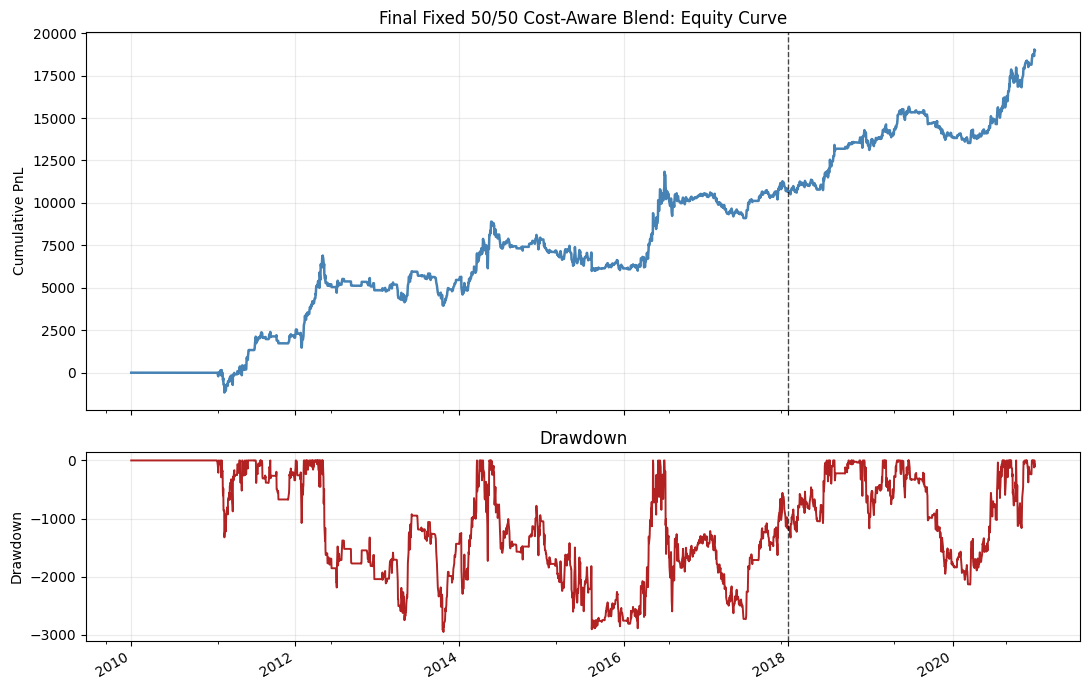

In [28]:
final_bt = final_strategy_results['final_backtest'].copy()
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

final_bt['cum_pnl'].plot(ax=axes[0], color='steelblue', linewidth=1.8)
axes[0].axvline(pd.Timestamp(SPLIT_DATE), color='black', linestyle='--', linewidth=1, alpha=0.7)
axes[0].set_title('Final Fixed 50/50 Cost-Aware Blend: Equity Curve')
axes[0].set_ylabel('Cumulative PnL')
axes[0].grid(True, alpha=0.25)

drawdown = final_bt['cum_pnl'] - final_bt['cum_pnl'].cummax()
drawdown.plot(ax=axes[1], color='firebrick', linewidth=1.4)
axes[1].axvline(pd.Timestamp(SPLIT_DATE), color='black', linestyle='--', linewidth=1, alpha=0.7)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown')
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


## Overfit Risk Assessment

Overfit risk by component:

| Component | Overfit risk | Status |
|---|---|---|
| Old broad one-day Ridge | High | Rejected as overfit |
| Static edge-filtered Ridge | Medium | Useful tradable baseline |
| Annual walk-forward Ridge | Medium-Low to Medium | Anti-overfit benchmark |
| 2-day skip-rebalance | Medium | Trading implementation candidate |
| Multi-condition opportunity filter | Medium-High | High-conviction sleeve |
| Final fixed 50/50 blend | Medium | Selected research candidate |

The final strategy is not low overfit risk because both components were selected during research. However, risk is reduced by fixed weights, cost adjustment, walk-forward evidence, and explicit rejection of the failed broad model.


## Next Steps

- Freeze the final rule.
- Test on 2021-2026 or newest unseen data.
- Stress transaction costs.
- Run leave-one-year-out robustness.
- Check regime performance.
- Calibrate position sizing and risk limits.
- Validate Cargill feature stability.


# Appendix

The appendix keeps the research archive available without making it part of the selected main path. These cells are for auditability, not for choosing a new final strategy in this notebook.


## Appendix A: Long Holding-Period Sweep

Detailed holding-period variants are shown here to document the implementation check. The main notebook uses only the 2-day skip-rebalance candidate.


In [29]:
hp_cols = ['strategy', 'method', 'hold_days', 'is_sharpe', 'oos_sharpe', 'oos_pnl', 'full_sharpe', 'max_drawdown', 'turnover']
holding_results['holding_period_table'][hp_cols].round(3)


,strategy,method,hold_days,is_sharpe,oos_sharpe,oos_pnl,full_sharpe,max_drawdown,turnover
0,Static edge-filtered,daily,1,0.930,1.498,10303.820,1.077,-4648.140,0.234
1,Static edge-filtered,skip-rebalance,2,0.862,1.730,11637.135,1.087,-4111.012,0.161
2,Static edge-filtered,skip-rebalance,3,0.792,1.441,9693.906,0.956,-4408.601,0.130
3,Static edge-filtered,skip-rebalance,5,0.886,1.213,7994.266,0.965,-4097.036,0.101
4,Static edge-filtered,skip-rebalance,10,0.634,0.633,4089.420,0.629,-4725.472,0.069
5,Static edge-filtered,staggered,2,0.903,1.413,9692.062,1.034,-4108.369,0.175
6,Static edge-filtered,staggered,3,0.857,1.320,9075.460,0.975,-4006.316,0.143
7,Static edge-filtered,staggered,5,0.937,1.110,7632.714,0.978,-3757.417,0.105
8,Static edge-filtered,staggered,10,0.874,0.937,6423.756,0.886,-4186.100,0.065
9,Static unfiltered,daily,1,0.558,1.087,9461.345,0.673,-7449.207,0.240


## Appendix B: Feature Attribution Diagnostics

Coefficient magnitudes are diagnostic only. They are not used to hand-tune the final rule.


In [30]:
core_scores = results['coefficients']['core'].abs().mean(axis=1).sort_values(ascending=False).to_frame('mean_abs_coef')
phys_scores = results['coefficients']['physical'].abs().mean(axis=1).sort_values(ascending=False).to_frame('mean_abs_coef')

display(core_scores.round(3))
display(phys_scores.round(3))


,mean_abs_coef
curve_spread,171.577
cot_mm_level,171.363
curve_ratio,147.173
cot_pm_oi_level,125.930
mom_60,76.982
rev_5,37.978


,mean_abs_coef
cgl_inventory_change,19.853
public_inventory_change,18.508
receipts_change,14.393
crush_utilization,12.614
crush_surprise,11.446


## Appendix C: Cost, Holding Cost, and Margin Stress

This audit applies common transaction-cost and margin assumptions across the candidate sleeves.


In [31]:
cost_results = gfs.run_cost_margin_experiment(DATA_DIR, split_date=SPLIT_DATE)['cost_margin_table']
cost_cols = [
    'strategy', 'case', 'trade_cost', 'holding_cost', 'total_cost',
    'is_sharpe', 'oos_sharpe', 'oos_pnl', 'max_dd', 'turnover'
]
cost_results[cost_cols].round(3)


/Users/phuongpham/phuong_project/cgl_challenge/strategy_backtest_research_bundle/support/grain_futures_strategy.py:98: FutureWarning: 'A-DEC' is deprecated and will be removed in a future version, please use 'YE-DEC' instead.
  pd.date_range(pd.Timestamp(start_date), index.max(), freq=retrain_frequency)


,strategy,case,trade_cost,holding_cost,total_cost,is_sharpe,oos_sharpe,oos_pnl,max_dd,turnover
0,Static edge-filtered,zero_cost_no_margin_cap,0.000,0.000,0.000,0.930,1.498,10303.820,-4648.140,0.234
1,Static edge-filtered,market_assumption,3840.082,913.105,4753.186,0.762,1.255,8637.787,-5027.694,0.234
2,Static edge-filtered,market_assumption_margin_cap,3680.552,876.815,4557.367,0.728,1.225,7900.533,-4993.376,0.225
3,Static edge-filtered,stress_cost_margin_cap,6309.518,1402.904,7712.422,0.611,1.055,6806.739,-5251.981,0.225
4,2-day skip-rebalance,zero_cost_no_margin_cap,0.000,0.000,0.000,0.862,1.730,11637.135,-4111.012,0.161
5,2-day skip-rebalance,market_assumption,2648.737,913.999,3562.736,0.733,1.550,10438.853,-4424.913,0.161
6,2-day skip-rebalance,market_assumption_margin_cap,2546.515,877.853,3424.367,0.695,1.539,9695.175,-4384.719,0.155
7,2-day skip-rebalance,stress_cost_margin_cap,4365.454,1404.565,5770.018,0.605,1.414,8914.686,-4597.211,0.155
8,Multi-condition filter,zero_cost_no_margin_cap,0.000,0.000,0.000,1.573,2.098,7555.641,-3405.688,0.338
9,Multi-condition filter,market_assumption,2219.704,371.193,2590.896,1.346,1.801,6502.007,-3728.537,0.338
